# Proyecto 1 — LSA con SVD

## 1. Elección y descripción del corpus

Elijan un corpus con al menos 50
documentos. Cada documento debe tener una cantidad razonable de texto y la
fuente debe ser abierta.
Describan la fuente de los datos, indiquen cuantos documentos usaran y
expliquen por que el corpus es interesante. Incluyan una tabla o resumen con el
numero de documentos y la fuente.
Algunos ejemplos posibles son abstracts de articulos cientificos, noticias, dis-
cursos politicos, letras de canciones, reviews de productos u otro corpus publico
que el grupo considere apropiado. Pueden buscar datos en Kaggle, Hugging Face
Datasets u otras fuentes abiertas.

In [400]:
import pandas as pd
import os
import re
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import matplotlib.pyplot as plt
import pandas as pd
from adjustText import adjust_text
import numpy as np
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity


Se usaran las letras de 500 canciones, poemas y libros (en su mayoria canciones) en español (filtradas manualmente en la celda anterior) de mas de 5 millones de datos recopilados por Genius en un dataset de Kaggle, del autor Nikhil Nayak, https://www.kaggle.com/datasets/carlosgdcj/genius-song-lyrics-with-language-information?resource=download . Es interesante ya que junta creaciones artisticas de todos los generos y estilos de todo el mundo, con gran variedad de años y artistas, de las canciones mas famosas a las desconocidas.

carlosgdcj. (2023). Genius song lyrics with language information. Kaggle. https://www.kaggle.com/datasets/carlosgdcj/genius-song-lyrics-with-language-information

In [401]:
df = pd.read_csv(os.path.join("data", "song_lyrics.csv"), nrows=1000000) 
df = df[df["language"] == "es"]
df = df[df["language_cld3"] == "es"]
df = df[df["language_ft"] == "es"]
df = df.sample(500, random_state=23) # Acortamos el df para realizar mas rapido los calculos sacando
# al azar (pero siempre replicable con los mismos datos por la semilla) 500 documentos
print(len(df))
#IMPORTANTE: si uno no pone limite, simplemente ningun computador es capaz de procesar tantas canciones, por ende solo analizaremos 1 M
df.head()

500


,title,tag,artist,year,views,features,lyrics,id,language_cld3,language_ft,language
623188,Adiccion,pop,Kabah,2015,12,{},"Ah, ahahah Ah, ahahah\nAh, ahahah Ah, ahahah\n...",929880,es,es,es
495993,Duende,pop,Miguel Bos,1987,965,"{""Miguel Bosé""}","[Letra de ""Duende""]\n\n[Intro]\n¿Hay alguien a...",793974,es,es,es
910420,Adorable Mentirosa,pop,Juan Gabriel,1998,143,{},Por que te encanta mentir\nAdorable mentirosa\...,1231004,es,es,es
599376,Quiero Volver a Mi Pueblo,pop,Mauricio & Palodeagua,2003,43,{},Se siente en la noche el lamento de un hombre\...,904099,es,es,es
944771,Mendigo,pop,La Fuga,2005,76,{},Prefiero ser mendigo que madero\nY recoger los...,1267103,es,es,es


In [402]:
letras = [letra for letra in df["lyrics"]]
letras[0]

'Ah, ahahah Ah, ahahah\nAh, ahahah Ah, ahahah\nHay que empezar, hay que indagar\nDe que nos vamos a enterar\nAveriguar quien va a fajar\nRezar, llorar, quien va a cojear\nCrecer, caer, creer, comer, querer y desobedecer\nEntretener, enfurecer y enloquecer\nHay que vivir, hay que sentir\nDe que lado van a dormir\nReir, fingir, quien va a sufrir\nMentir, seguir, quien va a salir\nTenor, actor, pintor, primor\nQuien es el peor, quien es mejor\nNominador y perdedor, aterrador\nBig Brother, Big Brother\nBig Brother, Big Brother V I P\n(Big Brother)\nBig Brother, Big Brother\nBig Brother, Big Brother V I P\nEs la adiccin\nQue regreso a televisin\nEn el domingo de expulsin\nQue no te pierdes\nY no por nada es la Adiccin\nLa que te da la comezn\nY no te paras del silln\nY no te mueves de Big Brother\nAhora quien ira a ganar\nA donde se iran a viajar\nQuien los ira a patrocinar\nReconocer quien va a tener\nTodo el poder de decidir\nY de escribir quien va a sufrir\nPredicador, profanador y espec

In [403]:
vectorizer_raw = CountVectorizer(
    lowercase=True,
    token_pattern=r"(?u)\b[^\W\d_]{3,}\b",
    min_df=1,
)

X_raw = vectorizer_raw.fit_transform(letras)
vocabulario_raw = vectorizer_raw.get_feature_names_out()
A_raw = X_raw.toarray().T

In [404]:
print("Forma de X_raw (documentos x terminos):", X_raw.shape)
print("Forma de A_raw (terminos x documentos):", A_raw.shape)
print("Primeros terminos del vocabulario:", vocabulario_raw[:30])

Forma de X_raw (documentos x terminos): (500, 13460)
Forma de A_raw (terminos x documentos): (13460, 500)
Primeros terminos del vocabulario: ['aaaaaahh' 'aaaaah' 'aaaaahh' 'aaaah' 'aaah' 'aaar' 'aae' 'aao'
 'abagnale' 'abajo' 'abandona' 'abandonaba' 'abandonada' 'abandonado'
 'abandonar' 'abandonas' 'abandone' 'abandones' 'abandono' 'abandonó'
 'abanico' 'abarca' 'abc' 'abdicción' 'abduzcan' 'abecedario' 'abel'
 'abierta' 'abiertas' 'abierto']


,estadistica,corpus_sin_limpieza
0,numero_documentos,500
1,numero_terminos,13460
2,forma_X_documentos_x_terminos,500 x 13460
3,forma_A_terminos_x_documentos,13460 x 500
4,entradas_no_cero,44315
5,densidad,0.0066
6,sparsity,0.9934


,estadistica,corpus_sin_limpieza
0,min,14.00
1,mediana,120.00
2,media,154.39
3,max,2630.00


,estadistica,corpus_sin_limpieza
0,min,10.00
1,mediana,67.00
2,media,88.63
3,max,1245.00


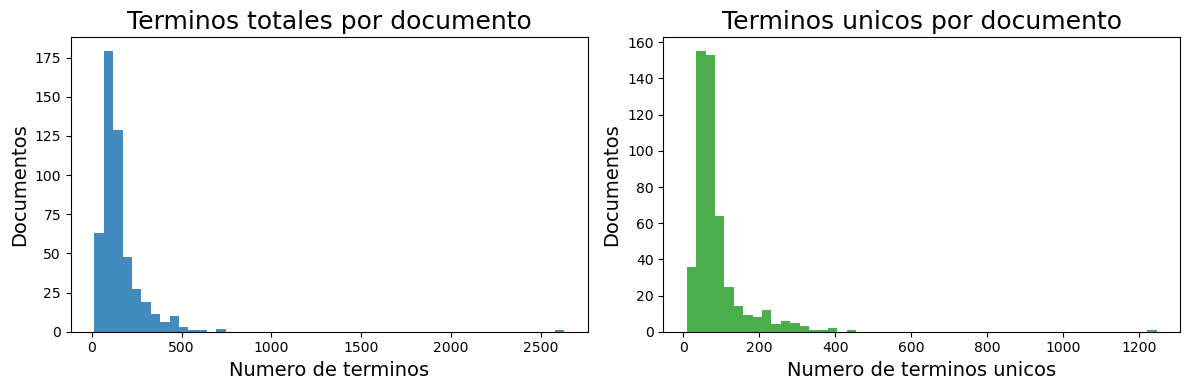

In [405]:
# Codigo del curso para facilitar la visualizacion, ajustando variables y parametros de los graficos a nuestros datos
def tabla_resumen_distribucion(nombre, valores):
    return pd.DataFrame(
        [
            ["min", int(valores.min())],
            ["mediana", int(np.median(valores))],
            ["media", round(float(valores.mean()), 2)],
            ["max", int(valores.max())],
        ],
        columns=["estadistica", nombre],
    )


def resumen_vectorizacion(nombre, X, A, vocabulario):
    conteos_por_doc = np.asarray(X.sum(axis=1)).ravel()
    terminos_unicos_por_doc = np.asarray((X > 0).sum(axis=1)).ravel()
    total_celdas = X.shape[0] * X.shape[1]
    densidad = X.nnz / total_celdas

    tabla_corpus = pd.DataFrame(
        [
            ["numero_documentos", X.shape[0]],
            ["numero_terminos", X.shape[1]],
            ["forma_X_documentos_x_terminos", f"{X.shape[0]} x {X.shape[1]}"],
            ["forma_A_terminos_x_documentos", f"{A.shape[0]} x {A.shape[1]}"],
            ["entradas_no_cero", X.nnz],
            ["densidad", round(float(densidad), 4)],
            ["sparsity", round(float(1 - densidad), 4)],
        ],
        columns=["estadistica", nombre],
    )
    tabla_terminos_por_doc = tabla_resumen_distribucion(nombre, conteos_por_doc)
    tabla_terminos_unicos_por_doc = tabla_resumen_distribucion(nombre, terminos_unicos_por_doc)

    return (
        tabla_corpus,
        tabla_terminos_por_doc,
        tabla_terminos_unicos_por_doc,
        conteos_por_doc,
        terminos_unicos_por_doc,
    )

(
    tabla_corpus_raw,
    tabla_terminos_por_doc_raw,
    tabla_terminos_unicos_por_doc_raw,
    conteos_doc_raw,
    terminos_unicos_doc_raw,
) = resumen_vectorizacion(
    "corpus_sin_limpieza",
    X_raw,
    A_raw,
    vocabulario_raw,
)

display(tabla_corpus_raw)
display(tabla_terminos_por_doc_raw)
display(tabla_terminos_unicos_por_doc_raw)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(conteos_doc_raw, bins=50, color="tab:blue", alpha=0.85)
axes[0].set_title("Terminos totales por documento", fontsize=18)
axes[0].set_xlabel("Numero de terminos", fontsize=14)
axes[0].set_ylabel("Documentos", fontsize=14)
axes[0].grid(False)

axes[1].hist(terminos_unicos_doc_raw, bins=50, color="tab:green", alpha=0.85)
axes[1].set_title("Terminos unicos por documento", fontsize=18)
axes[1].set_xlabel("Numero de terminos unicos", fontsize=14)
axes[1].set_ylabel("Documentos", fontsize=14)
axes[1].grid(False)

plt.tight_layout()
plt.show()

In [406]:
# Como el archivo original es muy pesado para subirlo al repositorio se creara una copia filtrada solo 
# con las letras que se usara en el proyecto para tener un archivo en el repositorio y se pueda replicar.
df.to_csv(os.path.join("data", "songs_lyrics_filtred.csv"))

## 2. Hipotesis inicial

Antes de realizar el analisis, propongan una hipotesis
sobre la estructura del corpus.

Por ejemplo, pueden anticipar temas posibles, grupos de documentos, palabras importantes o separaciones esperadas entre categorias. La salida esperada
es un parrafo corto con una hipotesis inicial concreta

Como hipotesis inicial esperamos que el SVD logre juntar canciones, poemas o libros se logren clasificar por decadas (80s, 90s, etc.) al comparar la similitud de las palabras que contienen.

## 3. Preprocesamiento del texto

Limpien el texto para construir un vocabulario util.

Como minimo, expliquen que decisiones tomaron sobre tokenizacion, normalizacion, eliminacion de stopwords y eliminacion de terminos poco informativos.

Se recomienda usar TF-IDF en lugar de conteos crudos. Tambien pueden incluirlematizacion y n-gramas si esto ayuda al corpus elegido.

Reporten el tamano del vocabulario final y expliquen brevemente por que el preprocesamiento elegido es razonable

In [407]:
# Primero para tokenizar separamos por palabras, dejando palabras como remix, ft, intro, etc, ya que igual puede ser una diferencia de epoca el usarlo
# y sacando los caracteres no alfanumericos como : o . , ya que no aportan informacion util

letras_filtradas = list()

for texto in letras:
    nuevo = list()
    # Usamos re para separar las palabras con varios posibles caracteres
    texto_separado = re.split(r"[ ,\n.:]", texto)
    for palabra in texto_separado:
        palabra_alfanumerica = str()
        for letra in palabra:
            if letra.isalpha() or letra.isdigit():
                palabra_alfanumerica += letra
        if len(palabra_alfanumerica) > 1:
            # solo agrega la palabra si tiene contenido util y no esta vacio o con solo 1 letra
            nuevo.append(palabra_alfanumerica)
    letras_filtradas.append(nuevo)

letras_filtradas[0]

['Ah',
 'ahahah',
 'Ah',
 'ahahah',
 'Ah',
 'ahahah',
 'Ah',
 'ahahah',
 'Hay',
 'que',
 'empezar',
 'hay',
 'que',
 'indagar',
 'De',
 'que',
 'nos',
 'vamos',
 'enterar',
 'Averiguar',
 'quien',
 'va',
 'fajar',
 'Rezar',
 'llorar',
 'quien',
 'va',
 'cojear',
 'Crecer',
 'caer',
 'creer',
 'comer',
 'querer',
 'desobedecer',
 'Entretener',
 'enfurecer',
 'enloquecer',
 'Hay',
 'que',
 'vivir',
 'hay',
 'que',
 'sentir',
 'De',
 'que',
 'lado',
 'van',
 'dormir',
 'Reir',
 'fingir',
 'quien',
 'va',
 'sufrir',
 'Mentir',
 'seguir',
 'quien',
 'va',
 'salir',
 'Tenor',
 'actor',
 'pintor',
 'primor',
 'Quien',
 'es',
 'el',
 'peor',
 'quien',
 'es',
 'mejor',
 'Nominador',
 'perdedor',
 'aterrador',
 'Big',
 'Brother',
 'Big',
 'Brother',
 'Big',
 'Brother',
 'Big',
 'Brother',
 'Big',
 'Brother',
 'Big',
 'Brother',
 'Big',
 'Brother',
 'Big',
 'Brother',
 'Big',
 'Brother',
 'Es',
 'la',
 'adiccin',
 'Que',
 'regreso',
 'televisin',
 'En',
 'el',
 'domingo',
 'de',
 'expulsin',
 'Qu

In [408]:
# Normalizamos las palabras haciendolas todas con letras minusculas
for texto in range(len(letras_filtradas)):
    for palabra in range(len(letras_filtradas[texto])):
        letras_filtradas[texto][palabra] = letras_filtradas[texto][palabra].lower()
        # saca los tildes para hacer todas iguales, transformandolo a un df para usar map 
        # y volviendolo a str solo si contiene una letra con tilde
        tiene = False
        for letra in letras_filtradas[texto][palabra]:
            if letra in {"á", "é", "í", "ó", "ú"}:
                tiene = True
                break
        if tiene:
            df = pd.DataFrame(list(letras_filtradas[texto][palabra]), columns=["caracteres"])
            letras_filtradas[texto][palabra] = "".join(df["caracteres"].map({"á": "a", "é": "e", "ú": "u", "í": "i", "ó": "o"}).fillna(df["caracteres"]))
letras_filtradas[0]

['ah',
 'ahahah',
 'ah',
 'ahahah',
 'ah',
 'ahahah',
 'ah',
 'ahahah',
 'hay',
 'que',
 'empezar',
 'hay',
 'que',
 'indagar',
 'de',
 'que',
 'nos',
 'vamos',
 'enterar',
 'averiguar',
 'quien',
 'va',
 'fajar',
 'rezar',
 'llorar',
 'quien',
 'va',
 'cojear',
 'crecer',
 'caer',
 'creer',
 'comer',
 'querer',
 'desobedecer',
 'entretener',
 'enfurecer',
 'enloquecer',
 'hay',
 'que',
 'vivir',
 'hay',
 'que',
 'sentir',
 'de',
 'que',
 'lado',
 'van',
 'dormir',
 'reir',
 'fingir',
 'quien',
 'va',
 'sufrir',
 'mentir',
 'seguir',
 'quien',
 'va',
 'salir',
 'tenor',
 'actor',
 'pintor',
 'primor',
 'quien',
 'es',
 'el',
 'peor',
 'quien',
 'es',
 'mejor',
 'nominador',
 'perdedor',
 'aterrador',
 'big',
 'brother',
 'big',
 'brother',
 'big',
 'brother',
 'big',
 'brother',
 'big',
 'brother',
 'big',
 'brother',
 'big',
 'brother',
 'big',
 'brother',
 'big',
 'brother',
 'es',
 'la',
 'adiccin',
 'que',
 'regreso',
 'televisin',
 'en',
 'el',
 'domingo',
 'de',
 'expulsin',
 'qu

In [409]:
# La misma terminal recomendo agregar la siguiente linea al saltar LookupError
nltk.download('stopwords')

# definimos los stopwords en espanol
stop_words_propias = list(stopwords.words("spanish"))

# hacemos lo mismo que la celda anterior para calzar las palabras con tilde y dejarlas sin
for stop_word in range(len(stop_words_propias)):
    df = pd.DataFrame(list(stop_words_propias[stop_word]), columns=["caracteres"])
    stop_words_propias[stop_word] = "".join(df["caracteres"].map({"á": "a", "é": "e", "ú": "u", "í": "i", "ó": "o"}).fillna(df["caracteres"]))



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\crist\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [410]:
# Codigo de la documentacion https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html 
vectorizer = TfidfVectorizer(stop_words=stop_words_propias, min_df=5, max_df=0.9)
# agregamos los parametros necesarios para usar las stopword en español, capturar univamente las 
# palabras en mas de 5 textos y menos del 90% de los textos y arreglar las tildes
X = vectorizer.fit_transform([" ".join(palabras) for palabras in letras_filtradas])
vectorizer.get_feature_names_out()
print(X.shape)

(500, 1427)


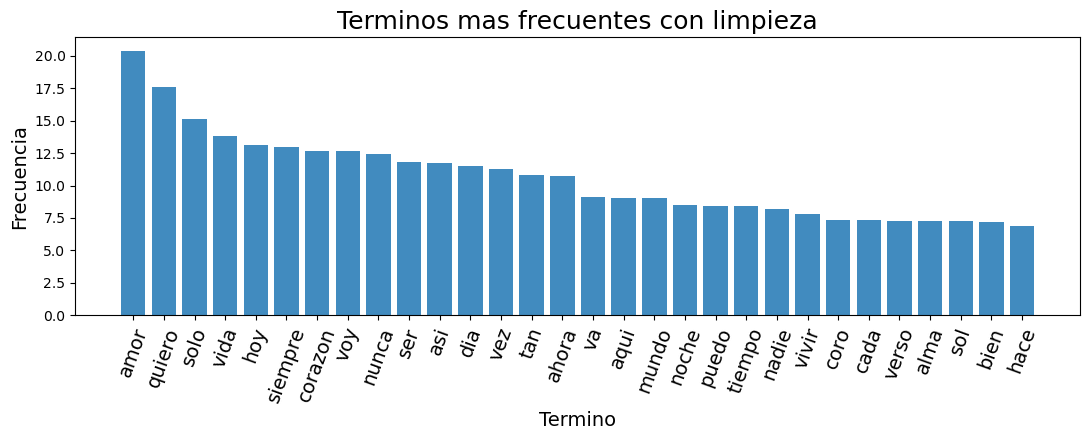

Top 30 terminos mas frecuentes con limpieza:


array(['amor', 'quiero', 'solo', 'vida', 'hoy', 'siempre', 'corazon',
       'voy', 'nunca', 'ser', 'asi', 'dia', 'vez', 'tan', 'ahora', 'va',
       'aqui', 'mundo', 'noche', 'puedo', 'tiempo', 'nadie', 'vivir',
       'coro', 'cada', 'verso', 'alma', 'sol', 'bien', 'hace'],
      dtype=object)

In [411]:
# Vemos las palabras mas frecuentes con el codigo entregado para ver si falto alguna stopword que
#  no estaba de forma predeterminada

vocabulario_raw = vectorizer.get_feature_names_out()

frecuencias_raw = np.asarray(X.sum(axis=0)).ravel()
indices_frecuentes_raw = np.argsort(frecuencias_raw)[::-1][:30]
terminos_frecuentes_raw = vocabulario_raw[indices_frecuentes_raw]
conteos_frecuentes_raw = frecuencias_raw[indices_frecuentes_raw]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(terminos_frecuentes_raw, conteos_frecuentes_raw, color="tab:blue", alpha=0.85)
ax.set_title("Terminos mas frecuentes con limpieza", fontsize=18)
ax.set_xlabel("Termino", fontsize=14)
ax.set_ylabel("Frecuencia", fontsize=14)
ax.grid(False)
ax.tick_params(axis="x", rotation=70, labelsize=14)
plt.tight_layout()
plt.show()

# Print top 30 terms and their counts
print("Top 30 terminos mas frecuentes con limpieza:")
terminos_frecuentes_raw

In [412]:
# Hacemos el nuevo X pero agregandole como stopwords "tan", "asi", "hace", "cada" , "coro"y "verso", ya que no aportan nada
# Codigo de la documentacion https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html 
stop_words_propias.append("tan")
stop_words_propias.append("asi")
stop_words_propias.append("hace")
stop_words_propias.append("cada")
stop_words_propias.append("verso")
stop_words_propias.append("coro")


vectorizer = TfidfVectorizer(stop_words=stop_words_propias, min_df=5, max_df=0.9)
# agregamos los parametros necesarios para usar las stopword en español, capturar univamente las 
# palabras en mas de 5 textos y menos del 90% de los textos y arreglar las tildes
X = vectorizer.fit_transform([" ".join(palabras) for palabras in letras_filtradas])
vectorizer.get_feature_names_out()
print(X.shape)

(500, 1421)


## 4. Construccion de la matriz textual

Construyan la matriz que sera analizada con SVD.

Definan claramente si trabajaran con una matriz termino-documento o documento-palabra. En la clase usamos la convencion

$$A \in \mathbb{R}^{m \times n},$$

donde las filas representan terminos, las columnas representan documentos, $m$ es el numero de terminos y $n$ es el numero de documentos. Si usan scikit-learn, recuerden que sus vectorizadores suelen entregar una matriz con documentos en las filas y terminos en las columnas; pueden transponerla si quieren seguir la convencion del curso.

Reporten la dimension de la matriz y expliquen como fue construida. Si usan TF-IDF, definan brevemente que representa una entrada $A_{ij}$.

In [413]:
# Para seguir la convencion del curso transponemos X y la guardamos en A
A = X.T
print(A.shape)

(1421, 500)


La dimension de A es de 1427 terminos x 500 documentos. 

Fue construida con TfidfVectorizer de scikit-learn sobre las 500 letras en español de las canciones, poemas o libros del dataset, tokenizando por palabra, normalizando a minuscula, eliminando tildes, filtrando stopwords en español y dejando un limite que nos sirva para entrenar de que cada termino se repita en al menos 5 documentos y que no aparezca en mas del 90% de los documentos, para quedarnos solo con las palabras importantes. Finalmente, como scikit-learn entregan una matriz con documentos en las filas y terminos en las columnas, se traspuso para seguir la convencion del curso.

Una entrada Aij representa el valor del termino i en el documento j, un peso alto indica que el termino i es frecuente en el documento j pero no tanto en el resto de los documentos, es como un peso que le asigna scikit-learn a cada termino segun cada documento.

## 5. Calculo de la SVD

Calculen la descomposicion

$$A = U\Sigma V^T.$$

Expliquen que representan los valores singulares en este problema y que informacion entregan los vectores singulares izquierdos y derechos. Si $A$ es una matriz termino-documento, las columnas de $U$ describen direcciones principales en el espacio de terminos, mientras que las columnas de $V$ describen direcciones principales en el espacio de documentos.

In [414]:
# Usamos el codigo entregado para descomponer en svd
U, s, VT = np.linalg.svd(A.toarray(), full_matrices=False)


In [415]:
print(U.shape, s.shape, VT.shape)

(1421, 500) (500,) (500, 500)


Teniendo en cuenta que A es una matriz real 1427 x 500 termino - documento, se descompone en sigma (s) vector real de tamaño 500 representando los valores singulares, donde cada valor singular mide el peso de cada tema de las letras, U matriz real 1427 x 500 que tiene puras columnas ortonormales representan de que trata cada tema de las letras, y en VT matriz real 500x500 en que cada fila representa en que canciones esta cada tema.

## 6. Valores singulares y eleccion de dimension

Analicen cuanto de la estructura del problema se concentra en pocas componentes.
Grafiquen los valores singulares, observen su decaimiento y elijan un valor razonable de $k$ para una representacion reducida. Justifiquen brevemente la eleccion de $k$.

Primeros valores singulares sin limpieza:
[4.375 2.23  2.11  1.995 1.941 1.873 1.864 1.809 1.794 1.773]


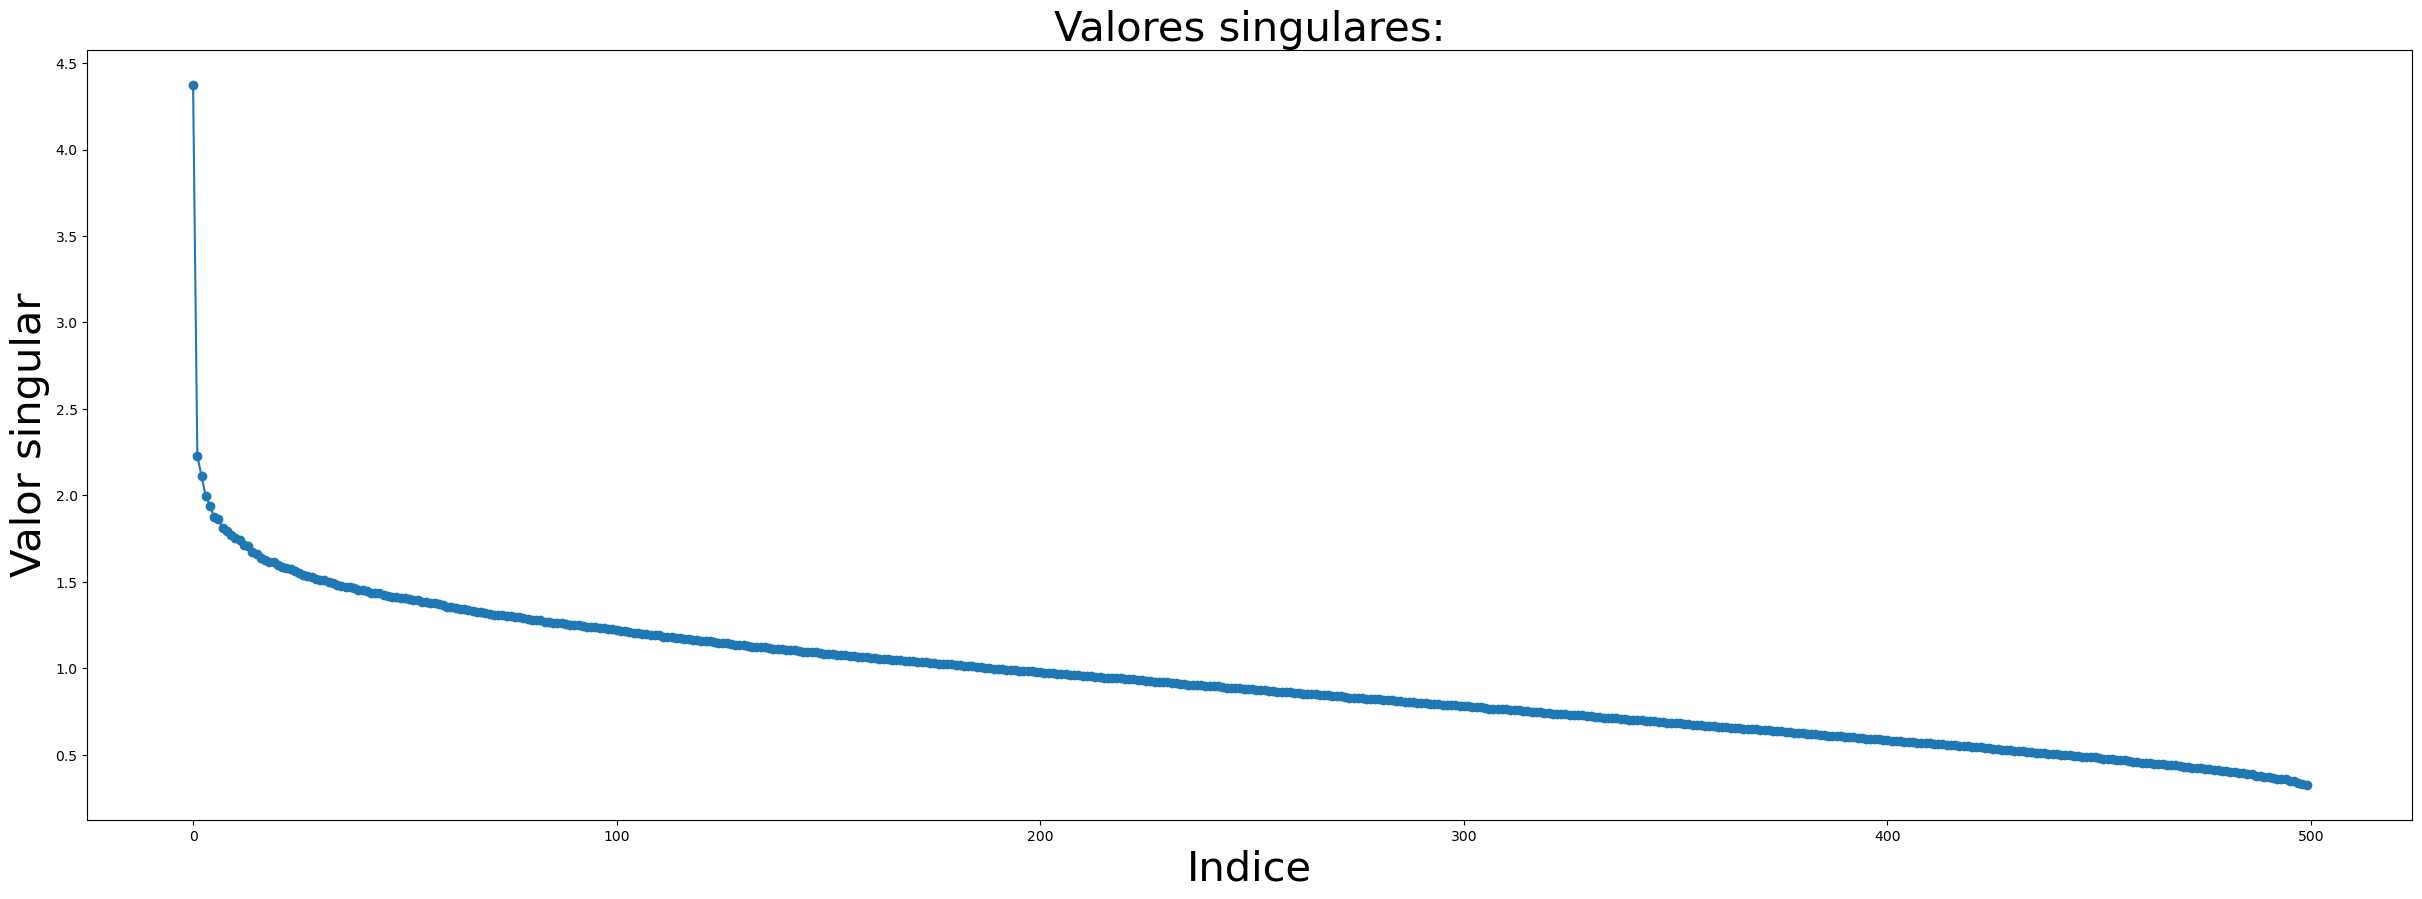

In [416]:
print("Primeros valores singulares sin limpieza:")
print(np.round(s[:10], 3))

plt.figure(figsize=(30, 10))
plt.plot(s, marker="o")
plt.title("Valores singulares:", fontsize=30)
plt.xlabel("Indice", fontsize=30)
plt.ylabel("Valor singular", fontsize=30)
plt.show()

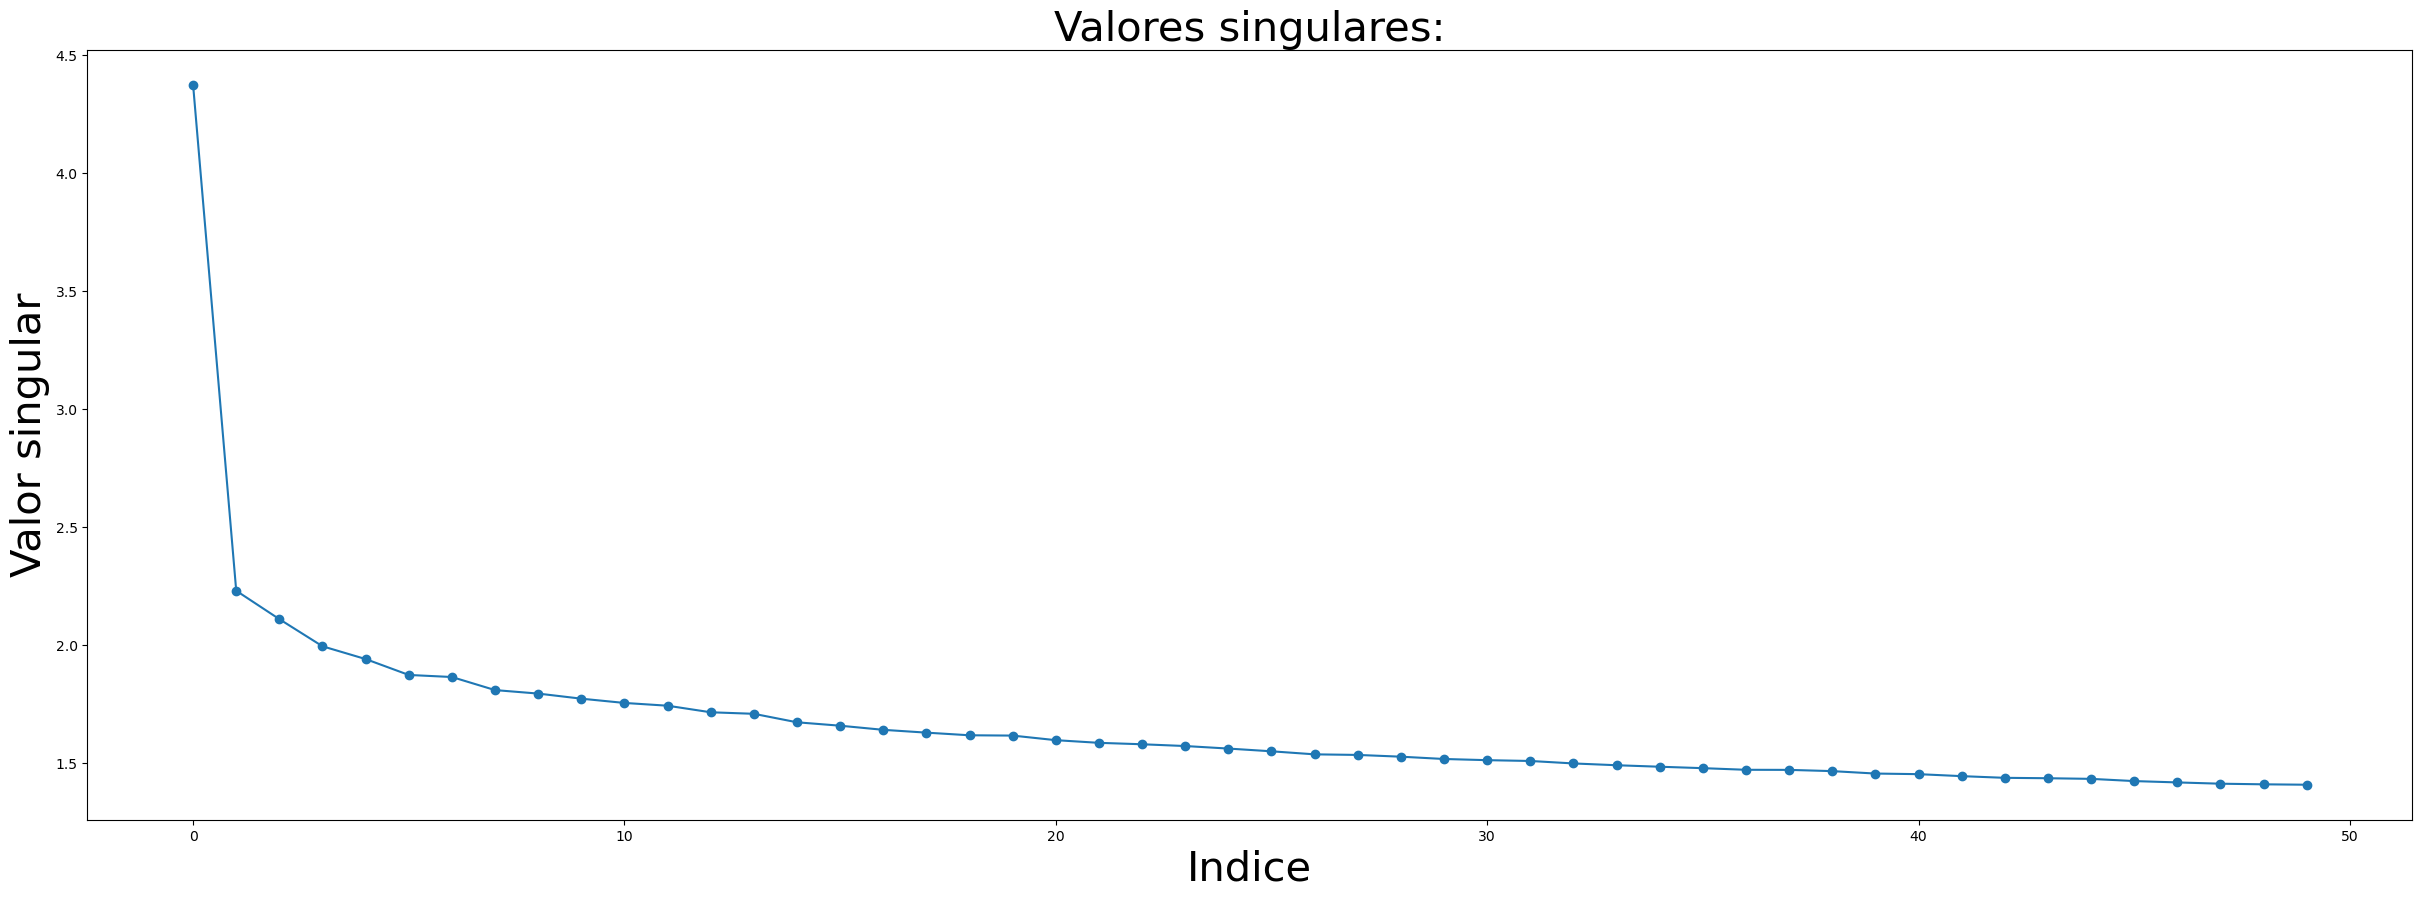

In [417]:
# Grafico enfocado en los primero valores para apreciar mejor
plt.figure(figsize=(30, 10))
plt.plot(s[:50], marker="o")
plt.title("Valores singulares:", fontsize=30)
plt.xlabel("Indice", fontsize=30)
plt.ylabel("Valor singular", fontsize=30)
plt.show()

Del grafico podemos ver que los primeros valores son muchos mas altos que los demas, despues no decrece tanto, por lo tanto el punto donde mas cambia el decrecimiento (al ver el grafico expandido) es alrededor del 2, por lo tango se elegira k=2.

## 7. Representacion de documentos y terminos en baja dimension

Usen componentes de la SVD para construir representaciones reducidas.
Para visualizar en dos dimensiones, pueden elegir cualquier par de componentes. En particular, es natural comenzar con las dos primeras componentes, porque corresponden a los dos valores singulares mas grandes. Si siguen la convencion termino-documento de la clase y escriben

$$A_2 = U_2 \Sigma_2 V_2^T,$$

para las dos primeras componentes, entonces las coordenadas de los documentos estan dadas por

$$D_2 = \Sigma_2 V_2^T \in \mathbb{R}^{2 \times n},$$

y las coordenadas de los terminos estan dadas por

$$T_2 = U_2 \Sigma_2 \in \mathbb{R}^{m \times 2}.$$

Mas generalmente, si quieren visualizar las componentes $a$ y $b$, usen las columnas correspondientes de $U$, las filas correspondientes de $V^T$ y los valores singulares $\sigma_a, \sigma_b$.
Incluyan una visualizacion 2D de documentos y una visualizacion 2D de palabras o terminos relevantes, indicando que par de componentes usaron. Interpreten agrupamientos, separaciones o asociaciones observadas.

In [418]:
# Creamus un nuevo df con las decadas de cada letra usando la misma semilla
# Para poder clasificarlos por decadas
df = pd.read_csv(os.path.join("data", "song_lyrics.csv"), nrows=1000000) 
df = df[df["language"] == "es"]
df = df[df["language_cld3"] == "es"]
df = df[df["language_ft"] == "es"]
df = df.sample(500, random_state=23)
df.head()

,title,tag,artist,year,views,features,lyrics,id,language_cld3,language_ft,language
623188,Adiccion,pop,Kabah,2015,12,{},"Ah, ahahah Ah, ahahah\nAh, ahahah Ah, ahahah\n...",929880,es,es,es
495993,Duende,pop,Miguel Bos,1987,965,"{""Miguel Bosé""}","[Letra de ""Duende""]\n\n[Intro]\n¿Hay alguien a...",793974,es,es,es
910420,Adorable Mentirosa,pop,Juan Gabriel,1998,143,{},Por que te encanta mentir\nAdorable mentirosa\...,1231004,es,es,es
599376,Quiero Volver a Mi Pueblo,pop,Mauricio & Palodeagua,2003,43,{},Se siente en la noche el lamento de un hombre\...,904099,es,es,es
944771,Mendigo,pop,La Fuga,2005,76,{},Prefiero ser mendigo que madero\nY recoger los...,1267103,es,es,es


In [419]:
df["year"] = (df["year"] % 100 // 10 * 10).astype(str) + "s"
df.sample()

,title,tag,artist,year,views,features,lyrics,id,language_cld3,language_ft,language
979692,Sin Ti,pop,Joanna (BR),10s,27,{},Sin ti no podré vivir jamás\nY pensar que nunc...,1303808,es,es,es


In [420]:
# Para esto usamos las funciones que nos ayudan a graficar del html, adaptandolo a que detecte las epocas (nuestra hipotesis)
    # Eliminare el texto del grafico, ya que como son muchos, no se aprecia bien

from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm


def coordenadas_documentos(s, VT, componentes=(1, 2)):
    indices = [componente - 1 for componente in componentes]
    return np.diag(s[indices]) @ VT[indices, :]


def coordenadas_terminos(U, s, componentes=(1, 2)):
    indices = [componente - 1 for componente in componentes]
    return U[:, indices] @ np.diag(s[indices])


def etiqueta_corta_documento(etiqueta):
    return Path(etiqueta).stem


def grupo_documento(etiqueta):
    
    return [decada for decada in df["year"].values][int(etiqueta)]


def colores_documentos(etiquetas_docs):
    grupos = [grupo_documento(etiqueta) for etiqueta in etiquetas_docs]
    decadas_ordenadas = sorted({grupo for grupo in grupos}, key=lambda d: int(d.rstrip("s")))
    cmap = plt.get_cmap("viridis")
    n = max(len(decadas_ordenadas) - 1, 1)
    mapa_colores = {d: cmap(i / n) for i, d in enumerate(decadas_ordenadas)}
    colores = [mapa_colores[grupo] for grupo in grupos]
    return grupos, colores, mapa_colores

def graficar_documentos_y_terminos(
    coords_docs,
    coords_terms,
    etiquetas_docs,
    vocabulario,
    frecuencias_terminos,
    titulo,
    componentes=(1, 2),
    n_terms=40,
):
    normas_terms = np.linalg.norm(coords_terms, axis=1)
    indices_terms = np.argsort(normas_terms)[::-1][:n_terms]
    term_freq = np.asarray(frecuencias_terminos).ravel()
    term_freq_plot = np.maximum(term_freq[indices_terms], 1)

    grupos_docs, colores_docs, mapa_colores_docs = colores_documentos(etiquetas_docs)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

    axes[0].scatter(
        coords_docs[0, :],
        coords_docs[1, :],
        s=95,
        c=colores_docs,
        edgecolor="white",
        linewidth=0.7,
    )
    # Eliminare el texto del grafico, ya que como son muchos, no se aprecia bien
    """texts_docs = []
    for i, etiqueta in enumerate(etiquetas_docs):
        texts_docs.append(
            axes[0].text(
                coords_docs[0, i],
                coords_docs[1, i],
                etiqueta_corta_documento(etiqueta),
                fontsize=11,
            )
        )
    axes[0].grid(False)
    adjust_text(
        texts_docs,
        ax=axes[0],
        expand_text=(1.25, 1.45),
        expand_points=(1.25, 1.45),
        force_text=(0.5, 0.7),
        force_points=(0.25, 0.35),
        arrowprops=dict(arrowstyle="-", color="0.45", lw=0.7),
    )"""
    axes[0].axhline(0, color="gray", linewidth=1.0)
    axes[0].axvline(0, color="gray", linewidth=1.0)
    axes[0].set_title("Documentos", fontsize=18)
    axes[0].set_xlabel(f"Componente {componentes[0]}", fontsize=14)
    axes[0].set_ylabel(f"Componente {componentes[1]}", fontsize=14)
    axes[0].tick_params(axis="both", labelsize=12)

    grupos_presentes = []
    for grupo in grupos_docs:
        if grupo not in grupos_presentes:
            grupos_presentes.append(grupo)
    handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label=grupo,
            markerfacecolor=mapa_colores_docs.get(grupo, "tab:brown"),
            markeredgecolor="white",
            markersize=10,
        )
        for grupo in grupos_presentes
    ]
    axes[0].legend(handles=handles, fontsize=10, loc="best", frameon=True, ncol=2)

    normalizador = LogNorm(vmin=max(term_freq_plot.min(), 1), vmax=max(term_freq_plot.max(), 1))
    scatter_terms = axes[1].scatter(
        coords_terms[indices_terms, 0],
        coords_terms[indices_terms, 1],
        s=75,
        c=term_freq_plot,
        cmap="viridis",
        norm=normalizador,
        edgecolor="white",
        linewidth=0.5,
    )
    texts_terms = []
    axes[1].grid(False)
    for i in indices_terms:
        texts_terms.append(axes[1].text(coords_terms[i, 0], coords_terms[i, 1], vocabulario[i], fontsize=10))
    adjust_text(
        texts_terms,
        ax=axes[1],
        expand_text=(1.2, 1.4),
        expand_points=(1.2, 1.4),
        force_text=(0.45, 0.65),
        force_points=(0.25, 0.35),
        arrowprops=dict(arrowstyle="-", color="0.45", lw=0.7),
    )
    axes[1].axhline(0, color="gray", linewidth=1.0)
    axes[1].axvline(0, color="gray", linewidth=1.0)
    axes[1].set_title("Terminos", fontsize=18)
    axes[1].set_xlabel(f"Componente {componentes[0]}", fontsize=14)
    axes[1].set_ylabel(f"Componente {componentes[1]}", fontsize=14)
    axes[1].tick_params(axis="both", labelsize=12)
    cax = axes[1].inset_axes([1.04, 0, 0.04, 1])
    cax.grid(False)
    cbar = fig.colorbar(scatter_terms, cax=cax)
    cbar.ax.grid(False)
    cbar.set_label("Frecuencia en el corpus", fontsize=12)
    cbar.ax.tick_params(labelsize=11)

    fig.suptitle(titulo, fontsize=20)
    plt.tight_layout()
    plt.show()






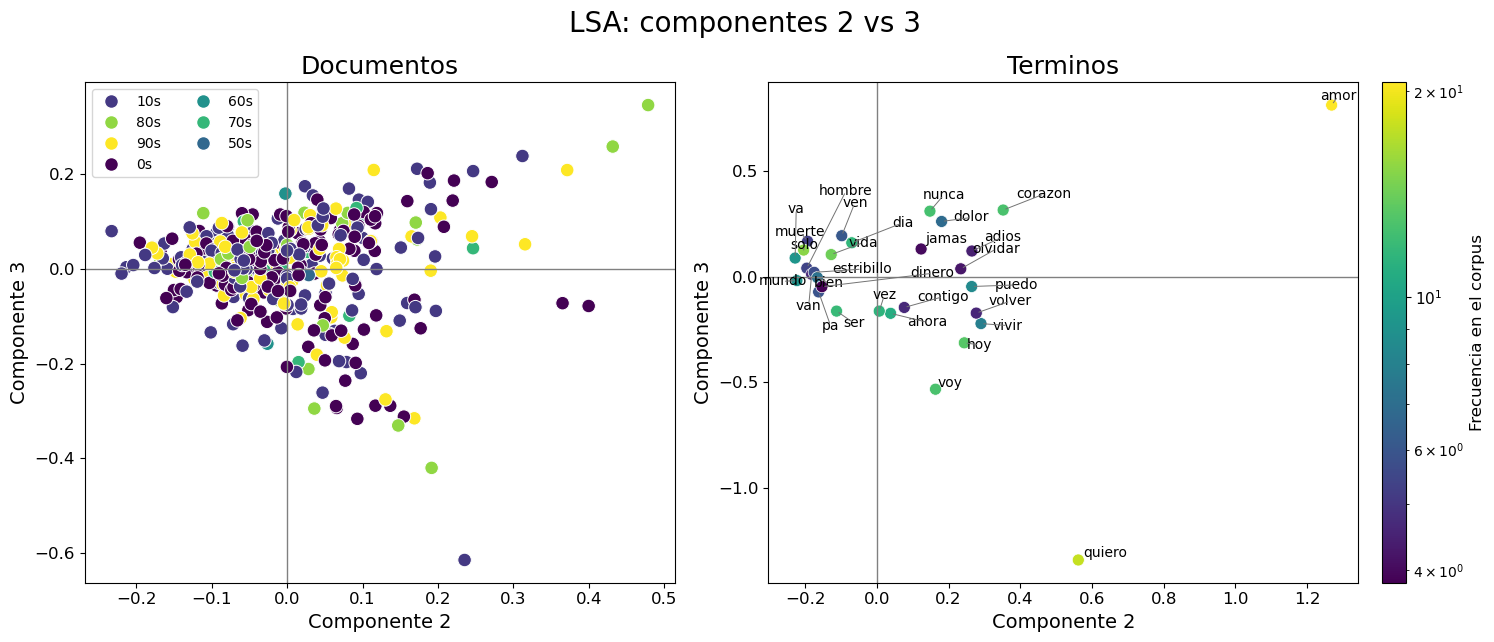

In [421]:
# Graficamos como se nos enseño cambiando los parametros segun nuestro codigo propio
docs_12_raw = coordenadas_documentos(s, VT, componentes=(2, 3))
terms_12_raw = coordenadas_terminos(U, s, componentes=(2, 3))

graficar_documentos_y_terminos(
    docs_12_raw,
    terms_12_raw,
    [str(i) for i in range(X.shape[0])], # En vez del poner el nombre de cada letra, le asignamos un numero
    vectorizer.get_feature_names_out(),
    np.asarray(X.sum(axis=0)).ravel(),
    "LSA: componentes 2 vs 3",
    componentes=(2, 3),
    n_terms=30,
)


Al ver los graficos, podemos apreciar que al menos visualmente no se agrupan por decadas, estan todas repartidas, por lo tanto la hipotesis no se puede validar de esta forma. Ademas se puede ver que las palabras amor y quiero aparece en gran mayoria del corpus, con gran diferencia.

## 8. Exploracion semantica

Usen la representacion reducida para explorar relaciones en el corpus.
Incluyan 2 o 3 ejemplos concretos, como palabras cercanas, documentos cercanos, componentes con posible significado tematico o grupos de documentos que parezcan relacionados. Expliquen por que esos ejemplos son coherentes o sorprendentes.

In [431]:
# Como se definio antes, k=2
k = 2
Uk = U[:, :k]
sk = s[:k]
VTk = VT[:k, :]
Tk = Uk * sk
Dk = (sk[:, None] * VTk).T


In [432]:
# Ejemplo 1 con palabras usuales en nuestro idioma, que se suele usar seguido en canciones u otras obras literarias
def vecino(palabra, Tk, vocabulario, n= 10):
    indice = int(np.where(vocabulario == palabra)[0][0])
    similitud = cosine_similarity(Tk[indice:indice + 1], Tk).ravel()
    similares = np.argsort(similitud)[::-1][1:n + 1]
    return pd.DataFrame({"termino": vocabulario[similares], "similitud": similitud[similares]})

for palabra in ["amor", "noche", "luna"]:
    if palabra in vectorizer.get_feature_names_out():
        print(f"Vecinos de {palabra}:")
        print(vecino(palabra, Tk, vectorizer.get_feature_names_out()))

Vecinos de amor:
      termino  similitud
0       adios   0.999867
1        rock   0.999860
2       podre   0.999314
3    perderte   0.998997
4      volver   0.998558
5     olvidar   0.998002
6  enloquecer   0.997927
7     regresa   0.997443
8        paga   0.997192
9      inutil   0.996903
Vecinos de noche:
   termino  similitud
0    sueño   1.000000
1  cobarde   0.999999
2      ave   0.999998
3  remedio   0.999998
4     olor   0.999997
5      dar   0.999997
6    hecha   0.999996
7   fuerte   0.999994
8    presa   0.999991
9   llegue   0.999983
Vecinos de luna:
      termino  similitud
0        veia   1.000000
1     escucha   1.000000
2        naci   1.000000
3     momento   1.000000
4       llora   0.999999
5   alrededor   0.999998
6        alba   0.999998
7       nacio   0.999995
8  existencia   0.999995
9       justo   0.999993


En este ejemplo comparamos las similitudes de palabras comunes en obras literarias, amor, noche y luna, donde todos los resultados fueron nada coherentes, ya que a pesar de que en amor lo asimilan a podre, regresa, adios, querido, marcho y lloro, palabras que estoy en demasiado acuerdo su similitud, al otro lado, con luna y noche erro completamente, ya que ninguna de sus palabras (o como maximo 2 de ellas) se asemeja a la palabra original, por lo tanto en este ejemplo, no sirve.

In [424]:
import random
# Ejemplo 2 con textos al azar de la misma fuente
random.seed(23)

def documentos_vecino(indice, Dk, df, n=5):
    similitud = cosine_similarity(Dk[indice:indice + 1], Dk).ravel()
    similares = np.argsort(similitud)[::-1][1:n + 1]
    return pd.DataFrame({"title": df.iloc[similares]["title"].values, "year": df.iloc[similares]["year"].values, "similitud": similitud[similares]})

for muestra in [random.randint(0, 500), random.randint(0, 500), random.randint(0, 500)]:
    print(f"{df.iloc[muestra]['title']} de la decada de los {df.iloc[muestra]['year']}")
    print(documentos_vecino(muestra, Dk, df, n=5))

Ángeles con una sola ala de la decada de los 0s
                                               title year  similitud
0                                    Días que Fueron  10s   0.999999
1                                              Soñar   0s   0.999995
2                                     Dos Solitarios  60s   0.999993
3  Cumbia Medley Como La Flor/La Carcacha/Bidi Bi...  90s   0.999988
4                                     Más de una vez   0s   0.999972
Olvida Mi Nombre de la decada de los 90s
                title year  similitud
0       No Hay Tiempo  10s   0.999998
1             Cambiar   0s   0.999995
2  No Hace Falta Nada  90s   0.999994
3    Si Comprendieras  90s   0.999986
4              Vuelve  90s   0.999983
El Día Que No Importaba de la decada de los 10s
                         title year  similitud
0               Cerebro mágico  90s   1.000000
1       La Custodia De Badillo  90s   1.000000
2                Hablame Claro   0s   0.999995
3              Te Iré A Buscar   

En este ejemplo comprobamos la hipotesis y vimos la similitud de un documento con 3 al azar. Con el primer documento acerto 2 de 5 y 1 fallo solo por 1 decada, por ende funciona parcialmente. En el segundo acerto en 3 de 5 y uno de los otros erro por solo 1 decada, por ende con el segundo se podria decir que algo funciona. Pero con el ultimo podemos ver que no le achunto a ninguno, por lo tanto definitivamente no funciona.

## 9. Discusion, limitaciones y conclusiones

Comparen los resultados con la hipotesis inicial.
Indiquen si la hipotesis se cumple o no, expliquen resultados esperados e inesperados, y discutan limites del metodo y del corpus. Recuerden que LSA no reemplaza la lectura del corpus: sirve como herramienta exploratoria para descubrir patrones, formular hipotesis y construir visualizaciones de baja dimension.

Al ver que en la P7 no se agrupaban correctamente las decadas, y despues fallaba en encontrar las similitudes tanto en palabras como en documentos, podemos decir que nuestra hipotesis es falsa, no se puede ver con SVD y LSA si dos textos liricos pertenecen a la misma epoca, haciendo todo esto un resultado totalmente inesperado, ya que como la forma de expresarse cambia en el tiempo, uno pensaria que esta seria una forma valida de clasificar por epoca segun el contenido de las obras literarias, y que no solo fallara la hipotesis, sino que tambien no hay nada en que este correcto con lo que se pueda defender. 